## 🧩 Atividade Complementar – Agrupamento de Texto e Modelagem de Tópicos - Capítulo 5

# 🟥 1. Instalação das bibliotecas

In [ ]:
# Esta célula instala todas as bibliotecas necessárias para o exercício.
# Execute antes de continuar.

!pip install sentence-transformers umap-learn hdbscan datasets bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 3.2 MB/s eta 0:00:00


# 🟥 2. Carregamento do dataset



*   Usaremos um dataset pequeno da HuggingFace com textos curtos para exemplificar fluxo de trabalho.
*   A tarefa consiste em extrair os textos e prepará-los para os próximos passos.




In [ ]:
'''
Neste passo, carregamos o conjunto de dados que será usado ao longo de todo o pipeline.
No livro "Hands-On Large Language Models", esse corresponde à etapa inicial do pipeline
de clustering e topic modeling: obter um conjunto de documentos textuais não estruturados.
Esses textos ainda NÃO possuem representação numérica e serão transformados em embeddings
nos próximos passos.

Aqui, estamos apenas preparando os dados e nos familiarizando com sua estrutura,
algo essencial antes de aplicar qualquer modelo de linguagem.
'''

from datasets import load_dataset

# DICA: estamos usando apenas uma parte do conjunto de treino (300 exemplos)
dataset = load_dataset("ag_news", split="_____[:300]")

# DICA: a coluna com os textos se chama "text"
texts = dataset["_____"]

# DICA: queremos saber quantos textos existem no dataset
print("Total de documentos:", _____(texts))
print(texts[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Total de documentos: 300
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


# 🟥 3. Criando embeddings com um modelo Transformer

* Transformaremos os documentos em representações vetoriais usando thenlper/gte-small, um modelo rápido e otimizado para similaridade semântica.

In [ ]:
'''
Neste passo, transformamos os textos em embeddings, que são representações numéricas
que capturam o significado semântico dos documentos.

De acordo com o Capítulo 5 do livro, esta é a PRIMEIRA etapa fundamental do pipeline
de text clustering e topic modeling:

1. Converter documentos em embeddings

Esses vetores serão usados posteriormente para reduzir dimensionalidade e agrupar
documentos semanticamente semelhantes. Sem embeddings, não é possível aplicar
clustering semântico de forma eficaz.
'''

from sentence_transformers import SentenceTransformer

# DICA: Iremos utilizar o modelo recomendado pelo livro gte-small
embedding_model = SentenceTransformer("thenlper/_____")

# DICA: queremos gerar embeddings para todos os textos do dataset
embeddings = embedding_model.encode(_____, show_progress_bar=True)

print("Formato dos embeddings:", embeddings.shape)

modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/66.7M [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Formato dos embeddings: (300, 384)


# 🟥 4. Redução de dimensionalidade com UMAP

* Embeddings de 384 dimensões são difíceis de clusterizar.
Usaremos UMAP para reduzir para apenas 5 dimensões.

In [ ]:
'''
Neste passo, aplicamos redução de dimensionalidade aos embeddings gerados anteriormente.
No pipeline apresentado no Capítulo 5 do livro "Hands-On Large Language Models",
esta é a SEGUNDA etapa fundamental:

2. Reduzir a dimensionalidade dos embeddings

Os embeddings gerados por modelos Transformer possuem alta dimensionalidade
(por exemplo, 384 dimensões). Embora ricos semanticamente, esses vetores
podem dificultar a aplicação de algoritmos de clustering.

Técnicas de redução de dimensionalidade, como o UMAP, permitem representar
os mesmos dados em um espaço menor, preservando ao máximo a estrutura global
e as relações semânticas entre os documentos.

No livro, o UMAP é escolhido em vez do PCA por lidar melhor com relações
não lineares e por ser especialmente eficaz em tarefas de clustering semântico.
'''

from umap import UMAP

# DICA: vamos reduzir os embeddings para um espaço com poucas dimensões (ex: 5)
# DICA 2: vamos utilizar a métrica recomendada pelo livro para embeddings -> cosine
umap_model = UMAP(
    n_components=_____,
    min_dist=0.0,
    metric="_____",
    random_state=42
)

# DICA: aplicamos o UMAP sobre os embeddings criados no passo anterior
reduced_embeddings = umap_model.fit_transform(_____)

# DICA: o número de documentos não muda, apenas a dimensionalidade
print("Nova dimensionalidade:", reduced_embeddings.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Nova dimensionalidade: (300, 5)


# 🟥 5. Clusterização com HDBSCAN

* Usaremos o algoritmo HDBSCAN, adequado para detectar clusters sem definir previamente quantos serão formados.

In [ ]:
'''
Neste passo, aplicamos o algoritmo de clusterização sobre os embeddings
que já passaram pela redução de dimensionalidade.

No Capítulo 5 do livro "Hands-On Large Language Models", esta é a TERCEIRA
e última etapa do pipeline de text clustering:

3. Encontrar grupos de documentos semanticamente semelhantes

Diferente de algoritmos como K-Means, o HDBSCAN é um método baseado em densidade,
o que significa que ele:
- NÃO exige definir previamente o número de clusters
- consegue identificar outliers (documentos que não pertencem a nenhum grupo)

Isso é especialmente útil em textos reais, onde nem todos os documentos
se encaixam claramente em um tema.
'''

from hdbscan import HDBSCAN


# DICA: iremos utilizar 10 como tamanho mínimo do cluster
# DICA 2: vamos utilizar a métrica usada após a redução de dimensionalidade -> euclidean
cluster_model = HDBSCAN(
    min_cluster_size=_____ ,
    metric="_____"
)

# DICA: aplicamos o modelo aos embeddings reduzidos
clusters = cluster_model.fit_predict(_____)

print("Clusters encontrados:", set(clusters))

Clusters encontrados: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(-1)}


# 🟥 6. Inspeção dos clusters

* Agora exploraremos documentos pertencentes ao mesmo cluster para entender seus temas.

In [ ]:
'''
Neste passo, fazemos a inspeção manual dos clusters gerados.

No livro "Hands-On Large Language Models", após aplicar o clustering,
o autor reforça a importância da avaliação humana dos resultados.
Antes de qualquer modelo de topic modeling automático, é fundamental
olhar exemplos reais de documentos dentro de um cluster para entender
se eles realmente compartilham um mesmo tema.

Essa etapa conecta os conceitos abstratos (embeddings e clusters)
de volta ao texto original, permitindo validar se o pipeline
está funcionando corretamente.
'''

import numpy as np

cluster_id = 0

# DICA: np.where retorna os índices dos documentos que pertencem ao cluster equivalente ao cluster_id
indices = np.where(clusters == _____)[0][:3]

for idx in indices:
    idx = int(idx)
    print(texts[idx])
    print("---")

Chad seeks refugee aid from IMF Chad asks the IMF for a loan to pay for looking after more than 100,000 refugees from conflict-torn Darfur in western Sudan.
---
Steady as they go BEDFORD -- Scientists at NitroMed Inc. hope their experimental drugs will cure heart disease someday. But lately their focus has been on more mundane matters.
---
Grant to aid Lynn Central Square Central Square in Lynn should be looking a bit brighter. New sidewalks, curbs, fences, lights, landscaping, and road improvements are planned for the Gateway Artisan Block, a key area of the square, with \$830,000 in state grant money given to Lynn last week.
---


# 🟥 7. Visualização dos clusters em 2D

* Aplicamos o BERTopic para gerar automaticamente tópicos com base nos textos e nos agrupamentos derivados internamente pelo modelo.

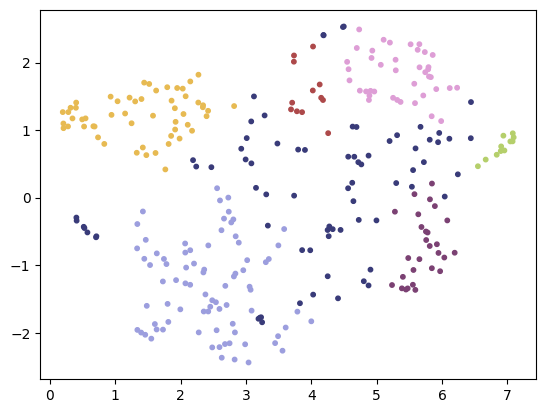

In [ ]:
'''
Neste passo, visualizamos os clusters em um espaço bidimensional.

No Capítulo 5 do livro "Hands-On Large Language Models", essa etapa é usada
para obter uma visão global da estrutura dos dados após o clustering.
Como não conseguimos visualizar espaços de alta dimensionalidade,
reduzimos novamente os embeddings para 2 dimensões apenas para fins
de visualização (x e y).

É importante destacar, como o livro reforça, que essa visualização
é apenas uma aproximação: parte da informação é perdida, e os clusters
podem parecer mais próximos ou mais distantes do que realmente são.
Ainda assim, ela é extremamente útil para análise exploratória.
'''

import matplotlib.pyplot as plt
from umap import UMAP

# DICA: reduzimos os embeddings originais para 2 dimensões para visualização
umap_2d = UMAP(n_components=_____).fit_transform(_____)

plt.scatter(umap_2d[:,0], umap_2d[:,1], c=clusters, cmap="tab20b", s=10)

plt.show()

# 🟥 8. Modelagem de tópicos com BERTopic

* Aplicamos o BERTopic para gerar automaticamente tópicos com base nos textos e nos agrupamentos derivados internamente pelo modelo.

In [ ]:
'''
Neste passo, utilizamos o BERTopic para realizar modelagem de tópicos.

Conforme discutido no Capítulo 5 do livro "Hands-On Large Language Models",
o BERTopic pode ser visto como uma EXTENSÃO natural do pipeline de
text clustering que construímos até aqui.

Internamente, o BERTopic combina:
- embeddings semânticos (Transformer)
- redução de dimensionalidade
- clusterização
- e uma etapa adicional de representação dos clusters como tópicos,
  usando técnicas como bag-of-words e c-TF-IDF.

Ou seja, agora deixamos de apenas agrupar documentos e passamos a
atribuir significado a esses grupos, representando-os como tópicos
descritos por palavras-chave.
'''

from bertopic import BERTopic

# instanciamos o modelo de topic modeling da biblioteca BERTopic
model_topic = _____()

# passamos a lista de textos que será usada para descobrir os tópicos
topics, probs = model_topic.fit_transform(_____)

model_topic.get_topic_info().head()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,25,-1_the_of_and_in,"[the, of, and, in, is, to, that, my, for, as]","[Ron Regan Jr is My Kinda Guy \\""Now that the ..."
1,0,150,0_the_of_to_ap,"[the, of, to, ap, and, in, for, is, space, on]",[China Begins Countdown for Next Manned Space ...
2,1,114,1_the_to_of_and,"[the, to, of, and, in, for, on, it, that, reut...",[Java3D - Half Right \\SUN has announced that ...
3,2,11,2_the_olympics_at_to,"[the, olympics, at, to, madden, football, spor...",[Olympics Could Call Out the Couch Potatoes As...


#### Neste exercício, aplicamos um pipeline completo de análise não supervisionada de textos de forma leve e rápida. Instalamos as bibliotecas necessárias, carregamos um dataset reduzido e geramos embeddings semânticos usando um modelo Transformer. Depois, reduzimos a dimensionalidade com UMAP, agrupamos os textos com HDBSCAN e inspecionamos exemplos de cada cluster. Também visualizamos os grupos em 2D e utilizamos o BERTopic para extrair tópicos automaticamente. Assim, percorremos todas as etapas essenciais de clusterização e modelagem de tópicos apresentadas no capítulo, colocando a teoria em prática de maneira objetiva e eficiente.